# Data exploration

In [2]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

from sentiment_analysis.utils import PATH_TRAINING_DATASET, PATH_CLEANED_TRAINING_DATASET

### load the dataset

In [3]:
movie_reviews = pd.read_csv(PATH_TRAINING_DATASET)

In [4]:
movie_reviews.shape

(49900, 2)

In [5]:
movie_reviews.describe()

,review,sentiment
count,49900,49900
unique,49484,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,24958


In [6]:
movie_reviews.head(5)

,review,sentiment
0,This short film that inspired the soon-to-be f...,positive
1,"Okay, last night, August 18th, 2004, I had the...",negative
2,I bought this game on an impulse buy from walm...,positive
3,"No, this hilariously horrible 70's made-for-TV...",positive
4,It is easy to tell early in this movie exactly...,negative


In [7]:
# Checking for missing values
movie_reviews.isnull().values.any()

np.False_

## Clean duplicates

In [8]:
# Counting duplicate rows
duplicate_count = movie_reviews.duplicated().sum()

print(f"Number of duplicate reviews found: {duplicate_count}")

Number of duplicate reviews found: 416


In [9]:
# remove duplicate rows
if duplicate_count > 0:
    movie_reviews.drop_duplicates(inplace=True)

print(f"New shape after removing duplicates: {movie_reviews.shape}")

New shape after removing duplicates: (49484, 2)


<Axes: xlabel='sentiment', ylabel='count'>

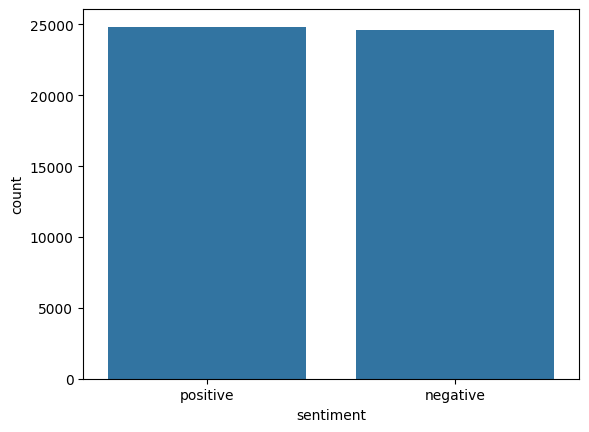

In [10]:
# Checking the distribution of positive/negative sentiments in the dataset
import seaborn as sns

sns.countplot(x='sentiment', data=movie_reviews)

In [11]:
# Calculating word count for each review
movie_reviews['review_len'] = movie_reviews['review'].apply(lambda x: len(x.split()))

print("Review Length Statistics")
print(movie_reviews['review_len'].describe())

Review Length Statistics
count    49484.000000
mean       231.345970
std        171.594435
min          4.000000
25%        126.000000
50%        173.000000
75%        281.000000
max       2470.000000
Name: review_len, dtype: float64


In [13]:
# preview a sample
movie_reviews["review"][2]

"I bought this game on an impulse buy from walmart. I am glad I did. It was very entertaining listening to Sean Connery and playing the game. I thought the graphics were the best I have ever seen in a movie/game remake. The bonus levels were very hard! The sniper one I think was too hard, it made me so frustrated I didn't play the game for a week and a half. There were too many people shooting at you with nothing to hide behind or life to handle it. <br /><br />The only thing I might change was the upgrade system. I didn't notice any difference from un-upgraded equipment to the upgraded, such as buying an armor upgrade didn't seem to make the armor stronger or more filling on my life meter. I really liked the Q copter. I think the developers did a good job."

In [14]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\andry\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [15]:
def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    text = text.lower()
    
    # Remove stopwords and short words (len < 2)
    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [w for w in words if w not in stop_words and len(w) > 1]
    
    return " ".join(words)

In [17]:
# sample cleaned output
clean_text(movie_reviews["review"][2])

'bought game impulse buy walmart glad entertaining listening sean connery playing game thought graphics best ever seen movie game remake bonus levels hard sniper one think hard made frustrated play game week half many people shooting nothing hide behind life handle thing might change upgrade system notice difference un upgraded equipment upgraded buying armor upgrade seem make armor stronger filling life meter really liked copter think developers good job'

In [18]:
# apply cleaning to the entire dataset
movie_reviews['review'] = movie_reviews['review'].apply(clean_text)

In [19]:
# sample cleaned output
clean_text(movie_reviews["review"][2])

'bought game impulse buy walmart glad entertaining listening sean connery playing game thought graphics best ever seen movie game remake bonus levels hard sniper one think hard made frustrated play game week half many people shooting nothing hide behind life handle thing might change upgrade system notice difference un upgraded equipment upgraded buying armor upgrade seem make armor stronger filling life meter really liked copter think developers good job'

In [20]:
movie_reviews.shape

(49484, 3)

In [21]:
# Converting sentiment labels to 0 & 1
movie_reviews['sentiment'] = movie_reviews['sentiment'].map({'positive': 1, 'negative': 0})

In [22]:
# preview cleaned data
movie_reviews.head()

,review,sentiment,review_len
0,short film inspired soon full length feature s...,1,137
1,okay last night august th distinct displeasure...,0,766
2,bought game impulse buy walmart glad entertain...,1,147
3,hilariously horrible made tv horror clinker de...,1,299
4,easy tell early movie exactly happen die women...,0,180


In [23]:
# Save the cleaned dataset
movie_reviews.to_csv(PATH_CLEANED_TRAINING_DATASET, index=False)